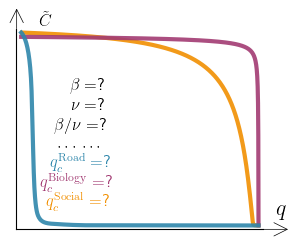

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.rcParams.update({
    'font.size': 24,
    'font.family': 'sans-serif',
    'text.usetex': True,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

COLORS = ['#F18F01', '#A23B72', '#2E86AB']  # Nature风格的颜色

# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(3.5, 3))


# 数据文件和对应的样式
data_files = [
    {"path": "OrPa/RNC1_L54572",   "xcol": 3, "ycol": 4, "marker": ">", "color": "#FCDC89", "label": "Social", "transform_x": lambda x: 1.0 - x},
    {"path": "OrPa/RNC1_L14340",   "xcol": 3, "ycol": 4, "marker": "X", "color": "#E26844", "label": "Biology", "transform_x": lambda x: 1.0 - x},
    {"path": "OrPa/RNC1_L2216688", "xcol": 3, "ycol": 4, "marker": "d", "color": "#8A233F", "label": "Road"   , "transform_x": lambda x: 1.0 - x},
]

# 读取并绘制数据
idx = -1
for file_info in data_files:
    idx = idx + 1
    path1 = file_info["path"]
    path2 = os.path.join(os.getcwd(), path1)

    data = np.loadtxt(path2)
    x_col = file_info["xcol"]
    y_col = file_info["ycol"]
    
    x = data[:, x_col-1]
    y = data[:, y_col-1]
    x = file_info["transform_x"](x)

    ax.plot(x, y, color=COLORS[idx], linewidth=3.0, alpha=0.9, label=file_info['label'], zorder=3)
    
#    ax.plot(x, y, marker=file_info["marker"], markersize=8, linestyle='', color=file_info["color"], label=file_info["label"], markeredgecolor='black', markeredgewidth=0.5)

# 设置坐标轴
#ax.set_xlabel('$q$', fontsize=16, loc='right', labelpad=-25, position=(1.55, 0.0))
# 删除原来的 xlabel
ax.set_xlabel('')
# 添加自定义位置的文本
ax.text(1.05, 0.15, '$q$', fontsize=16, transform=ax.transAxes, ha='left', va='top')
#ax.set_xlabel('$q$', fontsize=16, transform=ax.transAxes, x=1.05, y=0, ha='left', va='bottom')
ax.set_ylabel('$\\tilde{C}$', fontsize=12, loc='top', labelpad=-25, rotation=0)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels("")
ax.set_yticklabels("")

# 隐藏上、右轴线
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False)

# 添加箭头
# x轴箭头
ax.annotate('', xy=(1.1, -0.02), xycoords=('axes fraction', 'data'),
            xytext=(1.0, -0.02), textcoords=('axes fraction', 'data'),
            arrowprops=dict(arrowstyle='->', color='black', 
            lw=0.5, shrinkA=0, shrinkB=0))

# y轴箭头
ax.annotate('', xy=(-0.019, 1.1), xycoords=('data', 'axes fraction'),
            xytext=(-0.019, 1.0), textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle='->', color='black', 
            lw=0.5, shrinkA=0, shrinkB=0))

# 设置图例
#legend = ax.legend(loc='upper left', bbox_to_anchor=(1.02, 0.98),  fontsize=12, frameon=False, fancybox=False, edgecolor='black', framealpha=1.0)
ft1 = 12
ax.text(0.30-0.06, 0.1, r"$q_c^{ \mathrm{Social}}  = $?", color=COLORS[0], fontsize=ft1, ha='center')
ax.text(0.29-0.06, 0.2, r"$q_c^{ \mathrm{Biology}} = $?", color=COLORS[1], fontsize=ft1, ha='center')
ax.text(0.31-0.06, 0.3, r"$q_c^{ \mathrm{Road}}    = $?", color=COLORS[2], fontsize=ft1, ha='center')
ax.text(0.34-0.06, 0.7, '$\\beta = $?',        color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
ax.text(0.34-0.06, 0.6, '$\\nu =   $?',        color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
ax.text(0.31-0.06, 0.5, '$\\beta/\\nu = $?'  , color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
ax.text(0.31-0.06, 0.4, '$\\cdots$ $\\cdots$', color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)

# 调整布局，为图例留出空间
plt.tight_layout()  # 右侧留出15%空间给图例

plt.savefig("RNAttack.svg")

plt.show()